In [9]:
from argparse import ArgumentParser

import sys
import tensorflow as tf
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from constants import *
import os
import pandas as pd 
import re
from langchain_core.messages import AnyMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START, END

from typing import Annotated, List,Dict
from typing_extensions import TypedDict

from langchain_core.messages import SystemMessage,AIMessage,HumanMessage
from langchain_core.output_parsers import NumberedListOutputParser
from langgraph.graph.state import CompiledStateGraph
import os
from IPython.display import Image, display

In [10]:
class StateVector(TypedDict):
    seed_question: str
    country: str
    messages: Annotated[List[AnyMessage], add_messages] 
    topic: List[tuple[int, str]]  # List of tuples (topic_num, topic_name)
    topic_kw: Dict[str, List[str]] #  # Dictionary mapping topic names to lists of keywords
    questions: List[str] 

In [12]:
model_directory='../train_bert/topic_classifier_model'
loaded_tokenizer = AutoTokenizer.from_pretrained(model_directory)
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_directory).to_empty(device='cpu')
df_keys=pd.read_csv('../train_bert/training_data/Keyword_Patterns.csv')

In [26]:
###QUestion generating engine
def create_question_prompt_template(state: StateVector) -> StateVector:
    """
    Creates a prompt template based on the state vector.
    """
    state['messages'].extend([
            SystemMessage(
                content="You are an AI assistant that helps users find information about the Sustainable Development Goals (SDGs)."
            ),
            AIMessage(
                content="Hello, I am an assistant designed to help you learn about the 17 UN SDG goals listed here: https://sdgs.un.org/goals.\
                    You can ask me about any of the goals or specific topics, and I will provide you with information and resources related to them.\
                    I can also help you create a question related to the SDGs based on your input.\
                    Please provide me with a topic or question related to the SDGs and select a country, and I will do my best to assist you."
            )
        ])
    for topic, keywords in state['topic_kw'].items():
        state['messages'].append(SystemMessage(content=f"For the UN SDG Goal: {topic}\n. \
                                               Use the following keywords : {', '.join(keywords)}. Generate questions related to the topic in the country of {state['country']} using these keywords."))
    state['messages'].append(AIMessage(content="Based on the provided information, here is an enhanced version of the question:"))

    return state


#Check input raw prompt and extract topics and keywords
def check_inputs(state: StateVector) -> StateVector:
    """Check if topic and keywords are set"""
    #print(state)
    if not state.get('seed_question') or len(state.get('seed_question').strip())<3:
        raise ValueError("Seed question is not set in the state vector.")
    predict_input = loaded_tokenizer.encode(
        text=state.get('seed_question').lower(),
        truncation=True,
        padding=True,
        return_tensors="tf")
    output = loaded_model(predict_input)[0]
    prediction_value = tf.argmax(output, axis=1).numpy()#All answers
    prob_value=tf.nn.softmax(output).numpy()[0]#Probability of TF output
    Topic_Bool=prob_value>0.4
    Topics=[]
    Keywords={}
    for index, key in enumerate(sdg_goals):
        if not Topic_Bool[index]:continue
        #print(sdg_goals[key])
        Topics.append((index+1,sdg_goals[key]))
    for i,t in Topics:
        kw_patterns=df_keys[df_keys['topic_num']==i]['keywords'].values[0].split(',')
        Keywords[t] = re.findall(r'%s' %("|".join(kw_patterns)),raw_prompt)
        if not Keywords[t]:
            Keywords[t] = kw_patterns
            state['messages'].append(AIMessage(content="Will add keywords for the topic: %s" % t ))
        #print( Keywords[t])

    state['topic'] = Topics
    state['topic_kw'] = Keywords
    if not state.get('country'):
        state['messages'].append(AIMessage(content="Country is not set. Please provide a country."))
        return state
    elif not state.get('topic'):
        state['messages'].append(AIMessage(content="Missing topic please ask a question about the 17 Sustainable Development Goals. Graph will terminate."))
    state['messages'].append(AIMessage(content="Topics are: %s and keywords found: %s. Proceeding to prompt creation." \
                                    %(", ".join(Keywords.keys()), ", ".join([kw for kws in Keywords.values() for kw in kws]))))
    return state    

def should_continue(state: StateVector) -> str:
    """Determine whether to continue to prompt creation or terminate"""
    if not state.get('topic') or not state.get('topic_kw'):
        return "terminate"
    return "create_prompt_template"

def generate_questions(state: StateVector) -> StateVector:
    """
    Generates questions based on the provided topics and keywords.
    This is a placeholder function that can be extended to include more complex question generation logic.
    """
    parser=NumberedListOutputParser()
    runner= llm | parser
    #template= ChatPromptTemplate.from_messages(state['messages'][-2])
    result = runner.invoke(state['messages'])

    print("Generated Question: %s" %result)
    state['questions'] = result
    state['messages'].append(AIMessage(content="Generated questions: %s" % "\n".join(state['questions'])))
    return state


In [27]:
###Research engine: 
def direct_semantic_scholar_query(query: str):
    """Direct invocation of SemanticScholarQueryRun without agent"""
    
    # Create the tool directly
    tool = SemanticScholarQueryRun(
        api_wrapper=SemanticScholarAPIWrapper()
    )
    
    # Invoke the tool directly
    result = tool.invoke(query, k=10, output_parser=JsonOutputParser(), fields=["paperId","title","authors", "url","abstract","year","paperId"],sort="year")

    return result
def direct_tavily_search(query: str):
    """Direct invocation of TavilySearchResults without agent"""
    # Create the tool directly
    tavily = TavilySearchResults()
    result = tavily.invoke(query, max_results=5, include_answer=True, include_snippet=True, include_source=True)
    response=""
    for r in result:
        response +="Found a webpage: %s at %s" %(r['title'], r['url'])
        response +="Summary of the page: %s" %r['content']
        response +="Relevance score: %s" %r['score']
    return response

def data_analysis(state:StateVector):
    df_analyst=pd.read_csv('data_analysis/data_analyst_prompts.csv')
    analysis_prompt=[]
    topics=state['topic']
    for t in topics:
        Goal_Number=t[0]
        df_analyst=df_analyst[df_analyst['country']==state['country']]
        df_analyst['goal_number']=df_analyst['goal_number'].astype(int)
        df_analyst=df_analyst[df_analyst['goal_number']==Goal_Number]
        #print(df_analyst.head())

        if df_analyst.shape[0]>0:
            analysis_prompt.extend(df_analyst['analysis_prompt'].to_list())
    return "\n".join(analysis_prompt)


def create_prompt_template(state:StateVector) -> ChatPromptTemplate:

    """
    Creates a prompt template based on the provided questions.
    """
    topic_string = ", ".join(f"{name}" for num, name in state['topic'])
    keywords=[]
    kw_string=''
    for i,v in state['topic_kw'].items():
        keywords.append(",".join(v))
    kw_string += f" with keywords: {', '.join(keywords)}"
    messages = [
            SystemMessage(content= f"You are an AI assistant that helps users find information about the Sustainable Development Goal: {topic_string}.\
                          Your task is to answer questions related to this goal using the provided tools with toolNames: {tool_names}\
                              You will be provided with a list of questions to answer below: \
                              questions = {state["questions"]} "),

            #AIMessage(content="Using publications on Semantic Scholar and my own reference data, I will answer the questions related to the Sustainable Development Goal: %s." % topic),
            SystemMessage(content=f"Search for recent papers on {kw_string} in {state['country']}."),
            SystemMessage(content=f"Search for recent news on {kw_string} in {state['country']}."),
            SystemMessage(content=f"Search the internet for webpages on {kw_string} in {state['country']}."),
            #HumanMessage(content="Please provide a comprehensive answer to the questions based on the information gathered from the tools.")
        ]
    state['messages'] = messages
    return state

def tool_calling_agent():
    """Show how to bind the tool to LLM using tool calling"""
    
    # Initialize LLM
    llm = ChatOpenAI(
        temperature=0.1,
        model_name="gpt-4o-mini",
        openai_api_key=openai_api_key
    )
    # Create the tool
    semantic_scholar_tool = SemanticScholarQueryRun(
        api_wrapper=SemanticScholarAPIWrapper()
    )
    tools=[semantic_scholar_tool,direct_tavily_search]
    # Bind the tool to the LLM
    llm_with_tools = llm.bind_tools(tools)
    
    return llm_with_tools,tools


def tool_calling_llm(state:StateVector):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

def summary_answer(state:StateVector,google_api_key)->StateVector:
    """
    Function to summarize the answer from the LLM.
    This is a placeholder function that can be extended to include more complex summarization.
    """
    
    initial_system_message= state["messages"][0] # This is the system message that sets the context for the LLM with the listed questions
    initial_system_message.content += "Please provide a comprehensive answer to the questions. \n"
    
    tool_messages = [msg for msg in state["messages"] if isinstance(msg, ToolMessage)]
    augmented_data=""
    if tool_messages:
        initial_system_message.content += "Use the following information gathered from the tools as reference information: \n"
        
        for tool_msg in tool_messages:
            print(tool_msg.content, type(tool_msg.content))
            Label_Source=""
            if 'semanticscholar' in tool_msg.name.lower():
                Label_Source="(Source: Scholarly Publication Abstracts from Semantic Scholar)"
                augmented_data+= f"{tool_msg.content}\n"
            elif 'tavily' in tool_msg.name.lower():
                Label_Source="(Source: News Search Results)"
                augmented_data += f"{tool_msg.content}\n"
            else:
                print("Unknown Tool Call")

            initial_system_message.content += f"{Label_Source} \n {augmented_data}\n"
    analysis_prompt=data_analysis(state)
    print(analysis_prompt)
    initial_system_message.content+=analysis_prompt
    initial_system_message.content+="\n Assess if the resources indicate a general positive or negative trend and grade progress\
          from 0-10 where 0 is very negative and 10 is very positive.\n"
    initial_system_message.content+="\n Provide detailed answers to the questions and a list of references used."
    state["messages"].append(initial_system_message)
    '''
    llm = ChatOpenAI(
        temperature=0.4,
        model_name="gpt-4o",
        openai_api_key=openai_api_key
    )
    '''
    llm=ChatGoogleGenerativeAI(model='gemini-2.5-pro',google_api_key=google_api_key,temperature=0.3)
    
    #print(state["messages"][-1].content)
    airesponse = llm.invoke(state["messages"][-1].content)
    # For simplicity, we just return the messages as they are
    return {"messages": [airesponse]}

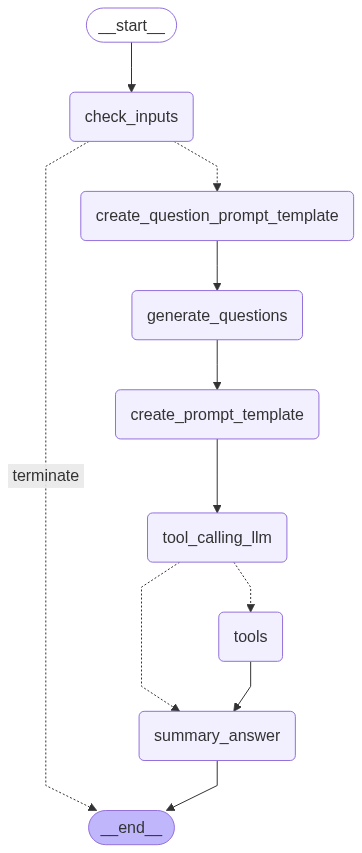

In [43]:
###Build graph for diagram:
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from langchain_community.tools.semanticscholar.tool import SemanticScholarQueryRun
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper
workflow = StateGraph(StateVector)
# Add nodes
workflow.add_node("check_inputs", check_inputs)
workflow.add_node("create_question_prompt_template", create_question_prompt_template)
workflow.add_node("generate_questions", generate_questions)
semantic_scholar_tool = SemanticScholarQueryRun(
    api_wrapper=SemanticScholarAPIWrapper()
)
workflow.add_node("tools", ToolNode(tools=[semantic_scholar_tool,direct_tavily_search]))
workflow.add_node("create_prompt_template", create_prompt_template)
workflow.add_node(summary_answer,name="summary_answer",
            description="Summarize the answer from the LLM using the information gathered from the tools.",)
workflow.add_node(tool_calling_llm,
            name="tool_calling_llm",
            description="Invoke the LLM with curated questions to answer.",)
# Set entry point
workflow.set_entry_point("check_inputs")
# Add conditional edges

workflow.add_conditional_edges(
    "check_inputs",
    should_continue,
    {
        "create_question_prompt_template": "create_question_prompt_template",
        "terminate": END
    }
)
workflow.add_edge("create_question_prompt_template", "generate_questions")
workflow.add_edge("generate_questions","create_prompt_template")


workflow.add_edge("create_prompt_template","tool_calling_llm")

workflow.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to Summary answer with no retrieved docs
    tools_condition,
    {
        "tools": "tools",
        "summary_answer": "summary_answer",
        # You might also want to handle other potential returns
    },
)
workflow.add_edge("tools", "summary_answer")
workflow.add_edge("summary_answer", END)

graph=workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png(output_file_path="FullResearchAgent.png")))
